In [106]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [107]:
# Read the car image
image = cv2.imread("car_image.jpeg")

In [108]:
# Initialize foreground and background markings
mask = np.zeros(image.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

In [170]:
# Define the region of interest (ROI) for the car
rect = (10, 10, 990, 800)  # (x, y, width, height)

In [171]:
# Perform graph cut optimization
cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 array([[ 4.35934731e-02,  7.08976232e-01,  1.98028462e-02,
          2.01786241e-01,  2.58412079e-02,  6.99100097e+01,
          7.45232964e+01,  8.05299844e+01,  2.76551705e-01,
          0.00000000e+00,  1.61484995e+02,  1.26974808e+02,
          1.36193358e+02,  1.40207754e+02,  8.80398138e-01,
          9.65965645e-01,  1.45692423e+02,  1.14149304e+02,
          1.21913627e+02,  1.27004889e+02,  1.12193061e+02,
          1.17780836e+02,  1.62906897e+01,  1.17780836e+02,
          1.24592030e+02,  1.55637103e+01,  1.62906897e+01,
          1.55637103e+01,  2.36575872e+01,  2.20159685e-01,
          0.00000000e+00,  1.93704854e+00,  0.00000000e+00,
          1.00000000e-02,  0.00000000e+00,  1.93704854e+00,
          0.00000000e+00,  3.29848363e+02,  4.67262248

In [172]:
# Create a mask where 0 and 2 indicate background, and 1 and 3 indicate foreground
mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

In [173]:
# Multiply the image with the mask to get the segmented car
segmented_image = image * mask[:, :, np.newaxis]

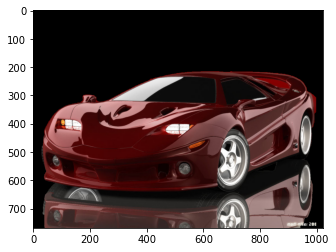

In [174]:
# Display the segmented image
plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))

plt.show()

(-0.5, 1023.5, 767.5, -0.5)

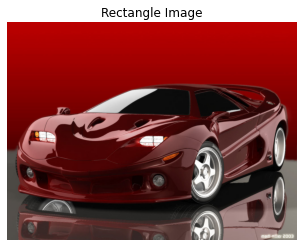

In [175]:
# Display the rectangle image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Rectangle Image")
plt.axis("off")

In [176]:
# Apply bilateral filter to improve clarity of the binary mask
filtered_mask = cv2.bilateralFilter(mask, 9, 75, 75)

In [177]:
# Multiply the image with the filtered mask to get the segmented car
segmented_image = image * filtered_mask[:, :, np.newaxis]

(-0.5, 1023.5, 767.5, -0.5)

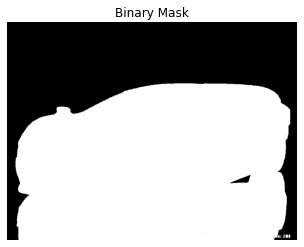

In [178]:
# Display the binary mask
plt.imshow(mask, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

(-0.5, 1023.5, 767.5, -0.5)

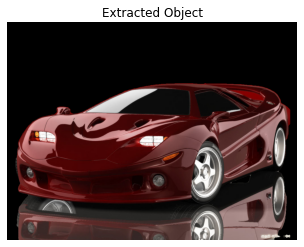

In [179]:
# Display the extracted object
plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))
plt.title("Extracted Object")
plt.axis("off")